In [1]:
# !pip install -U transformers
# !pip install -U accelerate
# !pip install -U datasets
# !pip install -U bertviz
# !pip install -U umap-learn
# !pip install -U sentencepiece
# !pip install -U urllib3
# !pip install py7zr
# !pip install -U pillow

# Image classification

## Load Dog and Cats dataset

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
from datasets import load_dataset

dataset = load_dataset("microsoft/cats_vs_dogs", split=['train'], trust_remote_code=True, ignore_verifications=True)


In [4]:
dataset
dataset = dataset[0].train_test_split(test_size=0.3, seed=42)

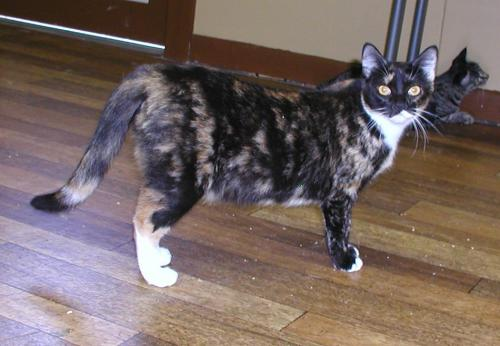

In [5]:
dataset["train"][0]['image'].size
dataset["train"][0]['image']

In [6]:
# resize the images to 224x224
def resize_image(example, size=(224, 224)):
    image = example['image']
    image = image.resize(size)
    example['image'] = image
    return example

dataset = dataset.map(resize_image)

Each example in the dataset has two fields:

- `image`: a PIL image of the food item
- `label`: the label class of the food item

To make it easier for the model to get the label name from the label id, create a dictionary that maps the label name
to an integer and vice versa:

In [7]:
labels = dataset["train"].features["labels"].names
label2id, id2label = dict(), dict()
for i, label in enumerate(labels):
    label2id[label] = str(i)
    id2label[str(i)] = label


Now you can convert the label id to a label name:

In [8]:
print(id2label)
print(label2id)

{'0': 'cat', '1': 'dog'}
{'cat': '0', 'dog': '1'}


## Preprocess

The next step is to load a ViT image processor to process the image into a tensor:

In [9]:
from transformers import AutoImageProcessor
import torch

# https://huggingface.co/google/vit-base-patch16-224-in21k

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

checkpoint = "google/vit-base-patch16-224-in21k"
image_processor = AutoImageProcessor.from_pretrained(checkpoint, use_fast=True)

Now create a batch of examples using [DefaultDataCollator](https://huggingface.co/docs/transformers/main/en/main_classes/data_collator#transformers.DefaultDataCollator). Unlike other data collators in 🤗 Transformers, the `DefaultDataCollator` does not apply additional preprocessing such as padding.

In [10]:
from transformers import DefaultDataCollator

data_collator = DefaultDataCollator()

## Evaluate

In [11]:
import evaluate

accuracy = evaluate.load("accuracy")

In [12]:
import numpy as np

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return accuracy.compute(predictions=predictions, references=labels)

Your `compute_metrics` function is ready to go now, and you'll return to it when you set up your training.

## Train

In [13]:
from transformers import AutoModelForImageClassification, TrainingArguments, Trainer

model = AutoModelForImageClassification.from_pretrained(
    checkpoint,
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id,
).to(device)

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [14]:
from torchvision.transforms import RandomResizedCrop, Compose, Normalize, ToTensor

normalize = Normalize(mean=image_processor.image_mean, std=image_processor.image_std)
size = (
    image_processor.size["shortest_edge"]
    if "shortest_edge" in image_processor.size
    else (image_processor.size["height"], image_processor.size["width"])
)
_transforms = Compose([RandomResizedCrop(size), ToTensor(), normalize])

def transforms(examples):
    examples["pixel_values"] = [_transforms(img.convert("RGB")) for img in examples["image"]]
    # del examples["image"]
    return examples

# dataset = dataset.with_transform(transforms)

In [15]:
dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'labels'],
        num_rows: 16395
    })
    test: Dataset({
        features: ['image', 'labels'],
        num_rows: 7027
    })
})

In [16]:
dataset = dataset.map(transforms, batched=True)

In [17]:
dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'labels', 'pixel_values'],
        num_rows: 16395
    })
    test: Dataset({
        features: ['image', 'labels', 'pixel_values'],
        num_rows: 7027
    })
})

In [18]:
training_args = TrainingArguments(
    output_dir="dog_cat_classification",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    num_train_epochs=5,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
)

trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    tokenizer=image_processor,
    compute_metrics=compute_metrics,
)

trainer.train()

  0%|          | 0/1285 [00:00<?, ?it/s]

  0%|          | 0/110 [00:00<?, ?it/s]

{'eval_loss': 0.054654669016599655, 'eval_accuracy': 0.9833499359612922, 'eval_runtime': 564.4566, 'eval_samples_per_second': 12.449, 'eval_steps_per_second': 0.195, 'epoch': 1.0}
{'loss': 0.0567, 'grad_norm': 0.029786206781864166, 'learning_rate': 3.054474708171206e-05, 'epoch': 1.95}


  0%|          | 0/110 [00:00<?, ?it/s]

{'eval_loss': 0.04573972150683403, 'eval_accuracy': 0.9867653337128219, 'eval_runtime': 533.7978, 'eval_samples_per_second': 13.164, 'eval_steps_per_second': 0.206, 'epoch': 2.0}


  0%|          | 0/110 [00:00<?, ?it/s]

{'eval_loss': 0.041852571070194244, 'eval_accuracy': 0.988757649067881, 'eval_runtime': 535.9065, 'eval_samples_per_second': 13.112, 'eval_steps_per_second': 0.205, 'epoch': 3.0}
{'loss': 0.0058, 'grad_norm': 0.01760006509721279, 'learning_rate': 1.1089494163424124e-05, 'epoch': 3.89}


  0%|          | 0/110 [00:00<?, ?it/s]

{'eval_loss': 0.04590550437569618, 'eval_accuracy': 0.9880461078696456, 'eval_runtime': 535.581, 'eval_samples_per_second': 13.12, 'eval_steps_per_second': 0.205, 'epoch': 4.0}


KeyboardInterrupt: 

In [ ]:
trainer.evaluate()

  0%|          | 0/440 [00:00<?, ?it/s]

{'eval_loss': 0.6555168032646179,
 'eval_accuracy': 0.6943219012380817,
 'eval_runtime': 78.7294,
 'eval_samples_per_second': 89.255,
 'eval_steps_per_second': 5.589,
 'epoch': 0.975609756097561}

In [ ]:
trainer.save_model("dog_cat_classification")

## Inference

Great, now that you've fine-tuned a model, you can use it for inference!

Load an image you'd like to run inference on:

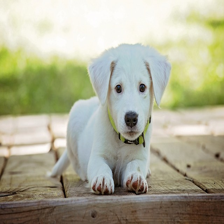

In [ ]:
# load dog image from online url

import requests
from PIL import Image
from io import BytesIO

url = "https://cdn.pixabay.com/photo/2016/12/13/05/15/puppy-1903313_640.jpg"
response = requests.get(url)
image = Image.open(BytesIO(response.content))

# show in 300x300
image = image.resize((224, 224))
image

In [ ]:
from transformers import pipeline

classifier = pipeline("image-classification", model="dog_cat_classification", device=device)
classifier(image)

[{'label': 'dog', 'score': 0.5687971115112305},
 {'label': 'cat', 'score': 0.43120288848876953}]